INITIALIZATION

In [ ]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
import sys
from scipy.ndimage import label, uniform_filter, binary_dilation, convolve, distance_transform_edt
from PIL import Image
np.set_printoptions(threshold=sys.maxsize)
from scipy.interpolate import splprep, splev
from io import StringIO

In [680]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
    return images
pics = np.zeros(shape=(7, 256, 256, 3))
pics = load_images_from_folder('C:\\Users\\2020\\Documents\\3 Academics\\Cambridge\\Publications\\Computer Vision\\Figures and Original Soln\\pics')

COMPRESSION

In [681]:
#Image-level complexity from local LAB standard deviation.
def local_lab_complexity_score(img_bgr, window_size=7, statistic="median"):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float64)

    # OpenCV LAB - standard-like LAB
    L = lab[:, :, 0] * (100.0 / 255.0)
    A = lab[:, :, 1] - 128.0
    B = lab[:, :, 2] - 128.0

    std_maps = []
    for ch in (L, A, B):
        mu = uniform_filter(ch, size=window_size, mode="reflect")
        mu2 = uniform_filter(ch * ch, size=window_size, mode="reflect")
        var = np.maximum(mu2 - mu * mu, 0.0)
        std_maps.append(np.sqrt(var))

    local_std = np.sqrt(std_maps[0]**2 + std_maps[1]**2 + std_maps[2]**2)

    if statistic == "mean":
        score = float(np.mean(local_std))
    else:
        score = float(np.median(local_std))

    return score, local_std

def adaptive_deltaE_threshold(complexity_score, low_complexity=2.0, high_complexity=12.0, high_thresh=10.0, low_thresh=4.0):
    # Low complexity - higher threshold
    # High complexity - lower threshold
    
    t = (complexity_score - low_complexity) / (high_complexity - low_complexity)
    t = np.clip(t, 0.0, 1.0)
    thresh = high_thresh * (1.0 - t) + low_thresh * t
    return float(thresh)

Adaptive complexity score: 2.027
Adaptive thresh (deltaE-like): 7.989


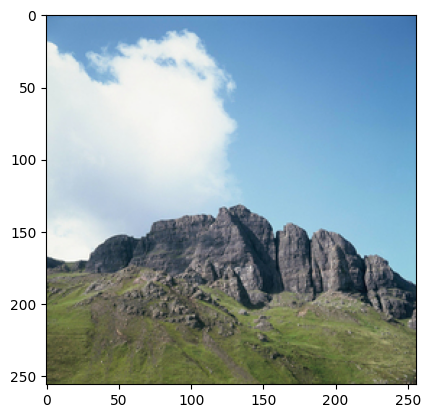

In [682]:
chosenImage = pics[13]

# Adaptive thresholding based on local LAB complexity
# calculate complexity score and local complexity map, indicates what areas are more complex
complexity_score, local_complexity_map = local_lab_complexity_score(chosenImage, window_size=7, statistic="median")

# color similarity threshold, usually 6-10 for deltaE
thresh = adaptive_deltaE_threshold(complexity_score, low_complexity=2.0, high_complexity=12.0, high_thresh=8.0, low_thresh=4.0)

print(f"Adaptive complexity score: {complexity_score:.3f}")
print(f"Adaptive thresh (deltaE-like): {thresh:.3f}")

# Color diversity score from CIELAB quantized bins
lab = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2LAB)

# Quantize channels
l_bin = (lab[:, :, 0] // 16).astype(np.int32)
a_bin = (lab[:, :, 1] // 16).astype(np.int32)
b_bin = (lab[:, :, 2] // 16).astype(np.int32)

key = l_bin * 16 * 16 + a_bin * 16 + b_bin
unique_colors = np.unique(key).size

if unique_colors < 75:
    pyrLevels = 1
elif unique_colors < 200:
    pyrLevels = 2
else:
    pyrLevels = 3

# Convert BGR to RGB for PIL (PIL expects RGB format)
chosenImageRGB = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
im = Image.fromarray(chosenImageRGB)
im.save('test.png')
im.save('test.jpg')
im.save('test.tiff')
plt.imshow(cv2.cvtColor(chosenImage, cv2.COLOR_RGB2BGR))
plt.show()

In [683]:
# Apply bilateral filter
chosenImageFiltered = cv2.bilateralFilter(chosenImage, d=7, sigmaColor=35, sigmaSpace=35)

# Convert input image to CIELAB (OpenCV 8-bit encoding)
img = cv2.cvtColor(chosenImageFiltered, cv2.COLOR_BGR2LAB)

# Remove old compressed file if it exists
if os.path.exists("imComp.txt"):
    os.remove("imComp.txt")

# imgClusters[i,j] = cluster number pixel belongs to
imgClusters = np.ones((img.shape[0], img.shape[1]), dtype=int)

# List of perimeter pixels for each cluster
clusterEdges = []

# visited[i,j] = 1 - pixel not yet assigned to any cluster
# visited[i,j] = 0 - pixel already assigned
visited = np.ones((img.shape[0], img.shape[1]), dtype=int)

clusterNum = 1              # current cluster ID
clustMeans = []             # mean LAB (OpenCV encoded) per cluster

# 8-connected neighborhood definition
structure = np.ones((3, 3), dtype=np.uint8)

# OpenCV LAB (8-bit) - approximate standard LAB:
# L*: [0,100], a*: [-128,127], b*: [-128,127]
img_f = img.astype(np.float64)
L_std = img_f[:, :, 0] * (100.0 / 255.0)
A_std = img_f[:, :, 1] - 128.0
B_std = img_f[:, :, 2] - 128.0

remaining = int(np.count_nonzero(visited))

# Continue until all pixels have been assigned
while remaining > 0:

    # Greedy assumption: all unvisited pixels could be in this cluster
    imgClusters[visited != 0] = clusterNum

    # ---- STEP 1: find the seed pixel and initialize cluster mean ----
    seed_positions = np.argwhere(visited == 1)
    if seed_positions.shape[0] == 0:
        break

    startX, startY = seed_positions[0]
    cMean = [[], [], []]
    cMean[0].append(img[startX, startY, 0])
    cMean[1].append(img[startX, startY, 1])
    cMean[2].append(img[startX, startY, 2])

    # ---- STEP 2: build the similarity mask (approx delta-E) ----
    seed_L = L_std[startX, startY]
    seed_A = A_std[startX, startY]
    seed_B = B_std[startX, startY]

    dL = L_std - seed_L
    dA = A_std - seed_A
    dB = B_std - seed_B

    # Euclidean distance in standard-like LAB coordinates
    dist = np.sqrt(dL**2 + dA**2 + dB**2)
    fitMask = (visited == 1) & (dist < thresh)

    # ---- STEP 3: connected component labeling (8-connected) ----
    labels, _ = label(fitMask, structure)

    # Label of the connected component containing the seed pixel
    seedLabel = labels[startX, startY]

    # region[i,j] = True ONLY for pixels reachable from the seed
    region = (labels == seedLabel)

    # ---- STEP 4: accept pixels in this connected component ----
    region_count = int(np.count_nonzero(region))
    if region_count == 0:
        # fallback so loop cannot stall forever
        visited[startX, startY] = 0
        imgClusters[startX, startY] = clusterNum
        region = np.zeros_like(visited, dtype=bool)
        region[startX, startY] = True
        region_count = 1

    visited[region] = 0
    imgClusters[region] = clusterNum
    remaining -= region_count

    # update cluster mean (stored in original OpenCV LAB encoding for downstream compatibility)
    region_pixels = img[region]
    cMean[0].extend(region_pixels[:, 0].tolist())
    cMean[1].extend(region_pixels[:, 1].tolist())
    cMean[2].extend(region_pixels[:, 2].tolist())

    # ---- STEP 5: border detection (vectorized 8-neighborhood) ----
    # Interior pixel has all 8-neighbors in region
    padded = np.pad(region, ((1, 1), (1, 1)), mode="constant", constant_values=False)
    up        = padded[:-2, 1:-1]
    down      = padded[2:, 1:-1]
    left      = padded[1:-1, :-2]
    right     = padded[1:-1, 2:]
    up_left   = padded[:-2, :-2]
    up_right  = padded[:-2, 2:]
    down_left = padded[2:, :-2]
    down_right= padded[2:, 2:]

    interior8 = up & down & left & right & up_left & up_right & down_left & down_right
    border_mask = region & (~interior8)

    border_idx = np.argwhere(border_mask)
    clust = [tuple(rc) for rc in border_idx]

    # ---- STEP 6: finalize this cluster ----
    clusterEdges.append(clust)

    clustMeans.append((
        int(np.rint(np.mean(cMean[0]))),
        int(np.rint(np.mean(cMean[1]))),
        int(np.rint(np.mean(cMean[2])))
    ))

    clusterNum += 1

In [684]:
# Trace the outer edge of a cluster of pixels.
# Returns ordered X and Y coordinates along the contour.
def traceClusterEdges(cluster):
    if len(cluster) == 0:
        return [], []

    # Convert cluster to set for O(1) membership check
    pixels = set(cluster)

    # clockwise starting from north
    directions = [(-1, 0), (-1, 1), (0, 1), (1, 1),
                  (1, 0), (1, -1), (0, -1), (-1, -1)]

    # Find starting pixel: top-left-most
    start = min(pixels, key=lambda c: (c[1], c[0]))
    x, y = start
    contour = [(x, y)]
    current = start
    prev_dir = 6  # start looking from left neighbor (south-west)

    while True:
        found_next = False
        # Check 8 neighbors clockwise starting from (prev_dir + 1)
        for i in range(8):
            idx = (prev_dir + 1 + i) % 8
            dx, dy = directions[idx]
            neighbor = (current[0] + dx, current[1] + dy)
            if neighbor in pixels:
                contour.append(neighbor)
                current = neighbor
                prev_dir = (idx + 4) % 8  # set new prev_dir opposite direction
                found_next = True
                break
        if not found_next or current == start:
            break

    # Separate X and Y
    X, Y = zip(*contour)
    return list(X), list(Y)

In [685]:
edgesSorted = []
for cluster in clusterEdges:
    xList, yList = traceClusterEdges(cluster)
    edgesSorted.append([xList, yList])

In [686]:
# Closed-contour B-spline helpers
def downsample_contour(contour_pts, stride=4):
    if len(contour_pts) <= 2:
        return contour_pts

    base = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    stride = max(1, int(stride))
    sampled = [base[i] for i in range(0, len(base), stride)]

    if len(sampled) < 4:
        sampled = base

    if sampled and sampled[0] != sampled[-1]:
        sampled.append(sampled[0])
    return sampled

def fit_closed_bspline(contour_pts, smooth=0.0, degree=3):
    if len(contour_pts) < 5:
        return None

    base = contour_pts[:-1]  # splprep(per=True) handles closure internally
    rows = np.array([p[0] for p in base], dtype=float)
    cols = np.array([p[1] for p in base], dtype=float)

    k = min(int(degree), len(base) - 1)
    if k < 1:
        return None

    try:
        tck, _ = splprep([rows, cols], s=float(smooth), per=True, k=k)
    except Exception:
        return None
    return tck

# Strict writer: write C only if geometry exists; Spline first, L fallback
def contour_area_rc(pts):
    # pts as [(row,col), ...], closed or open
    if len(pts) < 3:
        return 0.0
    base = pts[:-1] if pts[0] == pts[-1] else pts
    if len(base) < 3:
        return 0.0
    x = np.array([p[1] for p in base], dtype=float)
    y = np.array([p[0] for p in base], dtype=float)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

def enforce_closed_contour_rc(x, y):
    pts = [(int(r), int(c)) for r, c in zip(x, y)]
    if not pts:
        return []
    cleaned = [pts[0]]
    for p in pts[1:]:
        if p != cleaned[-1]:
            cleaned.append(p)
    if len(cleaned) < 3:
        return []
    if cleaned[0] != cleaned[-1]:
        cleaned.append(cleaned[0])
    return cleaned

def write_loop_L(f, contour_pts, max_pts=120):
    # L;r,c;r,c;...;
    base = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    if len(base) < 3:
        return False
    step = max(1, len(base) // max_pts)
    sampled = base[::step]
    if len(sampled) < 3:
        return False
    if sampled[0] != sampled[-1]:
        sampled.append(sampled[0])
    payload = ';'.join(f"{float(r):.4f},{float(c):.4f}" for r, c in sampled)
    f.write("L;" + payload + ";\n")
    return True

def fit_region_planar_model(img_color, region_mask):
    ys, xs = np.where(region_mask)
    if len(xs) < 3:
        # fallback: constant model as degenerate plane
        mean_col = img_color[ys, xs].mean(axis=0) if len(xs) > 0 else np.array([0, 0, 0], dtype=float)
        coef = np.zeros((3, 3), dtype=float)
        coef[:, 0] = mean_col
        return coef

    A = np.column_stack([np.ones_like(xs), xs, ys]).astype(np.float64)  # [1, x, y]
    vals = img_color[ys, xs].astype(np.float64)  # Nx3

    coef = np.zeros((3, 3), dtype=np.float64)
    for ch in range(3):
        coef[ch], *_ = np.linalg.lstsq(A, vals[:, ch], rcond=None)
    return coef

# contour_rc: list/array of points (closed or open), returns geometric complexity metrics for adaptive spline smoothing.
def contour_complexity_metrics(contour_rc):
    pts = np.asarray(contour_rc, dtype=np.float64)

    if len(pts) < 5:
        return {
            "perimeter": 0.0,
            "mean_turn": 0.0,
            "max_turn": 0.0,
            "corner_density": 1.0,
            "complexity": 1.0,
        }

    # Ensure closed contour
    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])

    diffs = np.diff(pts, axis=0)
    seg_lens = np.linalg.norm(diffs, axis=1)
    perimeter = float(np.sum(seg_lens))

    # Remove zero-length segments
    valid = seg_lens > 1e-8
    diffs = diffs[valid]
    seg_lens = seg_lens[valid]

    if len(diffs) < 3:
        return {
            "perimeter": perimeter,
            "mean_turn": 0.0,
            "max_turn": 0.0,
            "corner_density": 0.0,
            "complexity": 0.0,
        }

    unit = diffs / seg_lens[:, None]

    dots = np.sum(unit[:-1] * unit[1:], axis=1)
    dots = np.clip(dots, -1.0, 1.0)
    turns = np.arccos(dots)  # radians

    mean_turn = float(np.mean(turns))
    max_turn = float(np.max(turns))

    corner_threshold = np.deg2rad(35.0)
    corner_density = float(np.mean(turns > corner_threshold))

    # Combined complexity score ~[0,1]
    complexity = 0.6 * min(mean_turn / np.pi, 1.0) + 0.4 * corner_density

    return {
        "perimeter": perimeter,
        "mean_turn": mean_turn,
        "max_turn": max_turn,
        "corner_density": corner_density,
        "complexity": complexity,
    }

# Returns contour-adaptive splprep smoothing parameter s, Higher s: more smoothing/fewer control points, Lower s: tighter fit.
def adaptive_spline_smooth(contour_rc, min_smooth=0.0, max_smooth=20.0, base_perimeter=200.0):
    m = contour_complexity_metrics(contour_rc)

    perimeter = m["perimeter"]
    complexity = m["complexity"]

    # Larger contours can tolerate more total smoothing
    size_factor = max(perimeter / float(base_perimeter), 0.25)

    # More geometric complexity - less smoothing
    complexity_penalty = 1.0 - np.clip(complexity, 0.0, 1.0)

    s = max_smooth * size_factor * complexity_penalty
    s = float(np.clip(s, min_smooth, max_smooth))

    return s, m

In [687]:
min_points = 6
min_area = 4.0
encoded_ok = 0
fallback_ok = 0
dropped = 0
# Adaptive spline smoothing controls
SPLINE_MIN_SMOOTH = 0.0
SPLINE_MAX_SMOOTH = 20.0
SPLINE_BASE_PERIM = 200.0
#SPLINE_SMPOOTH = 1.0  

with open("imComp.txt", "w") as f:
    for i in range(len(edgesSorted)):
        x = edgesSorted[i][0]
        y = edgesSorted[i][1]

        contour = enforce_closed_contour_rc(x, y)
        if len(contour) < min_points or contour_area_rc(contour) < min_area:
            dropped += 1
            continue

        # Try spline first
        #tck = fit_closed_bspline(contour, smooth=SPLINE_SMOOTH, degree=3)
        s_val, contour_metrics = adaptive_spline_smooth(contour, min_smooth=SPLINE_MIN_SMOOTH, max_smooth=SPLINE_MAX_SMOOTH, base_perimeter=SPLINE_BASE_PERIM)
        tck = fit_closed_bspline(contour, smooth=s_val, degree=3)
        print(f"s={s_val:.2f}, perim={contour_metrics['perimeter']:.1f}, complexity={contour_metrics['complexity']:.3f}")

        wrote_geom = False
        geom_lines = []

        if tck is not None:
            t, c, k = tck
            cx, cy = c[0], c[1]
            if len(t) > 0 and len(cx) > 0 and len(cy) > 0:
                t_str = ",".join(f"{float(v):.6f}" for v in t)
                cx_str = ",".join(f"{float(v):.6f}" for v in cx)
                cy_str = ",".join(f"{float(v):.6f}" for v in cy)
                geom_lines.append("S;" + str(int(k)) + ";" + t_str + ";" + cx_str + ";" + cy_str + ";")
                wrote_geom = True

        # Fallback if spline failed
        if not wrote_geom:
            temp = StringIO()
            ok = write_loop_L(temp, contour, max_pts=120)
            if ok:
                geom_lines.append(temp.getvalue().strip())
                wrote_geom = True
                fallback_ok += 1

        if wrote_geom:
            # --- planar model fit ---
            cluster_id = i + 1
            region_mask = (imgClusters == cluster_id)
            coef = fit_region_planar_model(img, region_mask)

            m0 = ",".join(f"{v:.6f}" for v in coef[0])
            m1 = ",".join(f"{v:.6f}" for v in coef[1])
            m2 = ",".join(f"{v:.6f}" for v in coef[2])

            # M now starts a new region block
            f.write(f"M;{m0};{m1};{m2};\n")
            for line in geom_lines:
                f.write(line + "\n")
            f.write("\n")
            encoded_ok += 1
        else:
            dropped += 1

s=20.00, perim=676.0, complexity=0.204
s=7.79, perim=92.9, complexity=0.161
s=2.62, perim=27.8, complexity=0.476
s=3.12, perim=37.0, complexity=0.376
s=2.68, perim=19.3, complexity=0.463
s=20.00, perim=726.5, complexity=0.298
s=3.07, perim=17.1, complexity=0.386
s=13.21, perim=205.1, complexity=0.356
s=20.00, perim=607.5, complexity=0.309
s=2.37, perim=27.6, complexity=0.525
s=20.00, perim=462.7, complexity=0.386
s=4.71, perim=67.1, complexity=0.298
s=3.75, perim=56.5, complexity=0.337
s=2.65, perim=27.0, complexity=0.469
s=3.08, perim=36.4, complexity=0.383
s=5.94, perim=100.0, complexity=0.405
s=3.83, perim=67.6, complexity=0.433
s=18.72, perim=290.8, complexity=0.356
s=3.21, perim=34.7, complexity=0.358
s=20.00, perim=580.6, complexity=0.340
s=3.11, perim=8.8, complexity=0.379
s=3.22, perim=38.6, complexity=0.356
s=14.86, perim=243.3, complexity=0.389
s=20.00, perim=454.9, complexity=0.472
s=10.89, perim=209.0, complexity=0.479
s=2.75, perim=12.5, complexity=0.450
s=2.53, perim=38.9

DECOMPRESSION

In [ ]:
# Vectorized repair for unpainted pixels after reconstruction.
# Fills unpainted pixels that touch already-painted pixels by averaging their painted neighbors
# Repeats outward for up to max_iters.
def repair_coverage(imRecover, painted, max_iters=5, min_coverage=0.98):
    imRecover = imRecover.copy()
    painted = painted.astype(bool).copy()

    # 8-neighbor kernel, excluding center pixel
    kernel = np.ones((3, 3), dtype=np.float64)
    kernel[1, 1] = 0.0

    coverage = float(np.mean(painted))
    if coverage >= min_coverage:
        return imRecover, painted.astype(np.uint8), coverage

    for _ in range(max_iters):
        painted_float = painted.astype(np.float64)

        # Find unpainted pixels adjacent to painted pixels
        adjacent_to_painted = (binary_dilation(painted, structure=np.ones((3, 3), dtype=bool)) & (~painted))

        if not np.any(adjacent_to_painted):
            break

        # Count painted neighbors around every pixel
        neighbor_count = convolve(painted_float, kernel, mode="constant", cval=0.0)
        fillable = adjacent_to_painted & (neighbor_count > 0)

        if not np.any(fillable):
            break

        repaired = imRecover.astype(np.float64)

        # Average painted-neighbor colors for each channel
        for ch in range(imRecover.shape[2]):
            channel = imRecover[:, :, ch].astype(np.float64)
            neighbor_sum = convolve(channel * painted_float, kernel, mode="constant", cval=0.0)
            repaired[:, :, ch][fillable] = (neighbor_sum[fillable] / neighbor_count[fillable])

        imRecover = np.clip(repaired, 0, 255).astype(np.uint8)
        painted[fillable] = True

        coverage = float(np.mean(painted))
        if coverage >= min_coverage:
            break

    return imRecover, painted.astype(np.uint8), coverage

# Fallback: every unpainted pixel gets the color of the nearest painted pixel to remove all remaining unfilled spots
def repair_coverage_nearest(imRecover, painted):
    imRecover = imRecover.copy()
    painted_bool = painted.astype(bool)

    if np.all(painted_bool):
        return imRecover, painted_bool.astype(np.uint8), 1.0

    # distance_transform_edt returns indices of nearest zero pixel.
    nearest_indices = distance_transform_edt(~painted_bool, return_distances=False, return_indices=True)

    nearest_rows = nearest_indices[0]
    nearest_cols = nearest_indices[1]

    unpainted = ~painted_bool
    imRecover[unpainted] = imRecover[nearest_rows[unpainted], nearest_cols[unpainted]]
    painted_bool[unpainted] = True

    coverage = float(np.mean(painted_bool))
    return imRecover, painted_bool.astype(np.uint8), coverage

In [720]:
# 1. Initialize recovery image and list to track cluster sizes for sorting
imRecover = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
imRecover[:] = (255, 128, 128)
clusters_to_draw = []

# 2. Read the file once to collect all shapes and their data
with open("imComp.txt", "r") as f:
    current_cluster = None

    for line in f:
        l = line.strip().split(';')
        if len(l) == 0 or l[0] == '':
            continue

        # M signals start of a new cluster block
        if l[0] == 'M':
            ch0 = np.array([float(v) for v in l[1].split(',')], dtype=float)  # [a,b,c]
            ch1 = np.array([float(v) for v in l[2].split(',')], dtype=float)
            ch2 = np.array([float(v) for v in l[3].split(',')], dtype=float)

            current_cluster = {'pts': [], 'model': np.vstack([ch0, ch1, ch2]), 'area': 0.0}
            clusters_to_draw.append(current_cluster)

        elif l[0] == 'S' and current_cluster is not None:
            # S;degree;knots;ctrl_row;ctrl_col;
            k = int(l[1])
            t = np.array([float(v) for v in l[2].split(',')], dtype=float)
            cx = np.array([float(v) for v in l[3].split(',')], dtype=float)
            cy = np.array([float(v) for v in l[4].split(',')], dtype=float)

            tck = (t, [cx, cy], k)

            coarse_n = max(128, int(4 * len(cx)))
            coarse_rows, coarse_cols = splev(np.linspace(0.0, 1.0, coarse_n, endpoint=False), tck)

            drows = np.diff(np.r_[coarse_rows, coarse_rows[0]])
            dcols = np.diff(np.r_[coarse_cols, coarse_cols[0]])
            perimeter_estimate = np.sum(np.sqrt(drows**2 + dcols**2))

            n_samples = max(int(np.ceil(perimeter_estimate)), int(4 * len(cx)), 64)
            rows, cols = splev(np.linspace(0.0, 1.0, n_samples, endpoint=False), tck)

            for r, c in zip(rows, cols):
                rr = int(round(r))
                cc = int(round(c))
                current_cluster['pts'].append([cc, rr])

        elif l[0] == 'L' and current_cluster is not None:
            for tok in l[1:]:
                if not tok:
                    continue
                rc = tok.split(',')
                if len(rc) != 2:
                    continue
                r = int(np.clip(round(float(rc[0])), 0, img.shape[0]-1))
                c = int(np.clip(round(float(rc[1])), 0, img.shape[1]-1))
                current_cluster['pts'].append([c, r])  # x,y

# 3. Painter's algorithm sorted by polygon area
for cluster in clusters_to_draw:
    if len(cluster['pts']) > 2:
        polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))
        cluster['area'] = float(abs(cv2.contourArea(polygon_points)))
    else:
        cluster['area'] = 0.0

clusters_to_draw.sort(key=lambda x: x['area'], reverse=True)

# 4. Draw + track coverage (single pass)
H, W = imRecover.shape[:2]
painted = np.zeros((H, W), dtype=np.uint8)

drawn_clusters = 0
for cluster in clusters_to_draw:
    if len(cluster['pts']) > 2:
        polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))

        region = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(region, [polygon_points], color=1)
        ys, xs = np.where(region == 1)

        if len(xs) == 0:
            continue

        coef = cluster['model']  # shape (3,3)
        v0 = coef[0, 0] + coef[0, 1] * xs + coef[0, 2] * ys
        v1 = coef[1, 0] + coef[1, 1] * xs + coef[1, 2] * ys
        v2 = coef[2, 0] + coef[2, 1] * xs + coef[2, 2] * ys
        vals = np.stack([v0, v1, v2], axis=1)
        imRecover[ys, xs] = np.clip(vals, 0, 255).astype(np.uint8)

        painted[ys, xs] = 1
        drawn_clusters += 1

# 5. Coverage + repair
imRecover, painted, coverage = repair_coverage(imRecover, painted, max_iters=5, min_coverage=0.98)
if coverage < 1.0:
    imRecover, painted, coverage = repair_coverage_nearest(imRecover, painted)


Fish compress: 259203
JPEG compress: 9995
PNG compress: 105378
Tiff compress: 196748


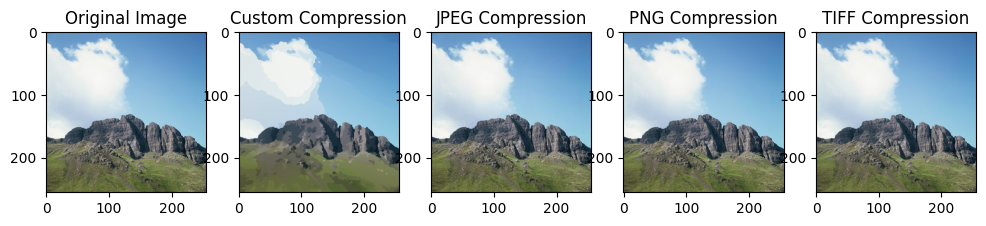

In [721]:
imj = cv2.imread('test.jpg')
imp = cv2.imread('test.png')
imt = cv2.imread('test.tiff')
f, axarr = plt.subplots(1,5, figsize=(12, 6))
axarr[0].imshow(chosenImage[...,::-1])
axarr[0].title.set_text('Original Image')
axarr[1].imshow(cv2.cvtColor(imRecover, cv2.COLOR_LAB2RGB))
axarr[1].title.set_text('Custom Compression')
axarr[2].imshow(imj[...,::-1])  # BGR to RGB for matplotlib
axarr[2].title.set_text('JPEG Compression')
axarr[3].imshow(imp[...,::-1])  # BGR to RGB for matplotlib
axarr[3].title.set_text('PNG Compression')
axarr[4].imshow(imt[...,::-1])  # BGR to RGB for matplotlib
axarr[4].title.set_text('TIFF Compression')

# Compare final compression to jpg and png
print("Fish compress:", os.path.getsize('imComp.txt'))
print("JPEG compress:", os.path.getsize('test.jpg'))
print("PNG compress:", os.path.getsize('test.png'))
print("Tiff compress:", os.path.getsize('test.tiff'))

In [722]:
# ---------- DCT helpers ----------
def jpeg_qtable_luma():
    return np.array([
        [16,11,10,16,24,40,51,61],
        [12,12,14,19,26,58,60,55],
        [14,13,16,24,40,57,69,56],
        [14,17,22,29,51,87,80,62],
        [18,22,37,56,68,109,103,77],
        [24,35,55,64,81,104,113,92],
        [49,64,78,87,103,121,120,101],
        [72,92,95,98,112,100,103,99]
    ], dtype=np.float32)

def quality_to_qtable(quality):
    q50 = jpeg_qtable_luma()
    q = int(np.clip(quality, 1, 100))
    scale = 5000 / q if q < 50 else 200 - 2*q
    qt = np.floor((q50 * scale + 50) / 100)
    qt = np.clip(qt, 1, 255).astype(np.float32)
    return qt

def pad_to_block(img, block=8):
    h, w, c = img.shape
    ph = (block - h % block) % block
    pw = (block - w % block) % block
    if ph == 0 and pw == 0:
        return img, (h, w)
    out = np.pad(img, ((0, ph), (0, pw), (0, 0)), mode="edge")
    return out, (h, w)

def psnr(a, b):
    a = a.astype(np.float32); b = b.astype(np.float32)
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return 99.0
    return 10*np.log10((255.0**2)/mse)

# ---------- Encode residual with DCT ----------
def encode_residual_dct(original_bgr, base_lab, quality=35, block=8):
    orig_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB).astype(np.int16)
    base_rgb = cv2.cvtColor(base_lab, cv2.COLOR_LAB2RGB).astype(np.int16)

    residual = (orig_rgb - base_rgb).astype(np.float32)
    residual_pad, (h0, w0) = pad_to_block(residual, block=block)
    hp, wp, _ = residual_pad.shape

    qt = quality_to_qtable(quality)
    qcoeff = np.zeros((hp, wp, 3), dtype=np.int16)

    for ch in range(3):
        for y in range(0, hp, block):
            for x in range(0, wp, block):
                blk = residual_pad[y:y+block, x:x+block, ch]
                d = cv2.dct(blk)
                qblk = np.round(d / qt).astype(np.int16)
                qcoeff[y:y+block, x:x+block, ch] = qblk

    return {
        "qcoeff": qcoeff,
        "h0": h0,
        "w0": w0,
        "quality": int(quality),
        "block": int(block)
    }

# ---------- Decode residual + add to base ----------
def decode_residual_dct(base_lab, payload):
    qcoeff = payload["qcoeff"].astype(np.float32)
    h0, w0 = payload["h0"], payload["w0"]
    quality, block = payload["quality"], payload["block"]

    base_rgb = cv2.cvtColor(base_lab, cv2.COLOR_LAB2RGB).astype(np.float32)
    base_pad, _ = pad_to_block(base_rgb, block=block)

    hp, wp, _ = qcoeff.shape
    qt = quality_to_qtable(quality)
    residual_hat = np.zeros((hp, wp, 3), dtype=np.float32)

    for ch in range(3):
        for y in range(0, hp, block):
            for x in range(0, wp, block):
                qblk = qcoeff[y:y+block, x:x+block, ch]
                d_hat = qblk * qt
                blk_hat = cv2.idct(d_hat)
                residual_hat[y:y+block, x:x+block, ch] = blk_hat

    recon_pad = np.clip(np.round(base_pad + residual_hat), 0, 255).astype(np.uint8)
    return recon_pad[:h0, :w0, :]


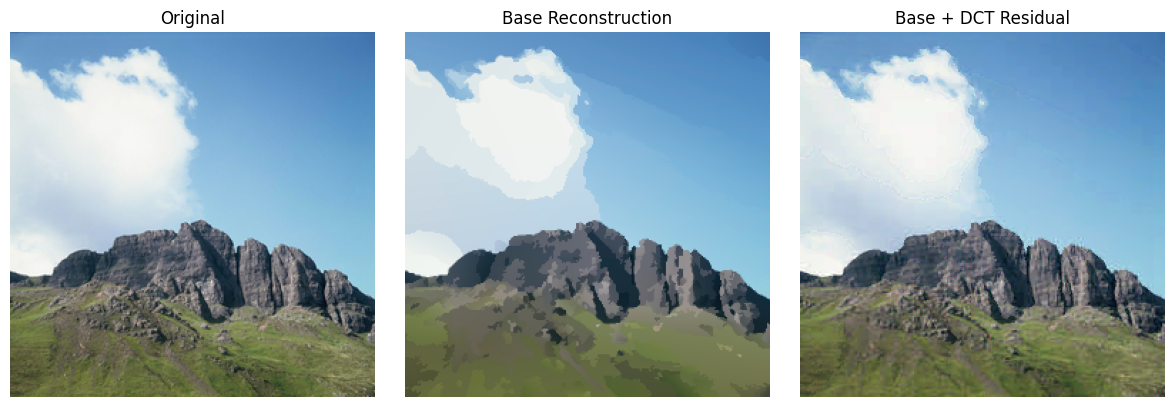

In [723]:
payload = encode_residual_dct(chosenImage, imRecover, quality=35, block=8)
final_rgb = decode_residual_dct(imRecover, payload)

orig_rgb = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
base_rgb = cv2.cvtColor(imRecover, cv2.COLOR_LAB2RGB)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(orig_rgb);  ax[0].set_title("Original")
ax[1].imshow(base_rgb);  ax[1].set_title("Base Reconstruction")
ax[2].imshow(final_rgb); ax[2].set_title("Base + DCT Residual")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()
